In [27]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer

from scipy.stats import pearsonr
from scipy.stats import spearmanr

## Read files

In [28]:
work_folder = '../data/'
os.chdir(work_folder)

fig_save_path = '../figures/'

All duplicated data

Top 100 results ranked by structrue and sequence similarity seperately

Using duplicated nanobody data from INDI database

Each nanobody is generated 1 structure

In [29]:

target_list_path = os.path.join(work_folder, 'INDI_database/dupl_INDI_passed_cleaned.tsv')
target_list_df = pd.read_csv(target_list_path, sep='\t')

connector_generation_folder = os.path.join(work_folder, 'batch_graft_generation/')

### Original structure + structure similarity + sequence similarity

Bit score；对 raw 进行长度和统计校正后得分，越大表明匹配越可靠

nident	完全相同氨基酸个数

In [30]:
def read_generations(target_list_df, generation_folder):
    # 初始化空列表来存储每次循环生成的 DataFrame
    all_results = []
    success = fail = 0

    region_list = ['all', 'connector1', 'connector2', 'connector3']
    # embe_list = ['raw_embeddings', 'pre_q_embeddings', 'q_embeddings', 'ca_distance']
    embe_list = ['raw_embeddings', 'pre_q_embeddings', 'ca_distance']

    for pdb_id in target_list_df['pdb_id']: 
        pdb_folder = os.path.join(generation_folder, pdb_id)
        
        # 读取 all_generation.tsv
        target = 'all'   # passed or selected
        file_name = 'all' if target == 'full' else target
        generation_tsv = os.path.join(pdb_folder, f'temp_generation/{target}_info/{file_name}_generation.tsv')

        # 如果文件不存在，则警告并跳过
        if not os.path.exists(generation_tsv):
            print(f"[WARNING] Skipped {pdb_id}: {generation_tsv} do not exist")
            fail += 1
            continue

        generation_df = pd.read_csv(generation_tsv, sep='\t')

        try:
            # 读取Distance file
            for region in region_list:
                for embe in embe_list:
                    # NOTE be careful for filename formate
                    original_distance_file_path = os.path.join(pdb_folder, 'similarity', f'{embe}_similarity_{region}.tsv')
                    # generated_distance_file_path = os.path.join(pdb_folder, 'generation_tokenized_structure', f'{embe}_distance_{region}.tsv') 
                    generated_distance_file_path = os.path.join(pdb_folder, 'generation_tokenized_structure', f'{embe}_similarity_{region}.tsv') # Lastest          
                    
                    original_distance_df = pd.read_csv(original_distance_file_path, sep='\t').rename(
                        columns={'euclidean': f'original_euclidean_{region}_{embe}', 'cosine': f'original_cosine_{region}_{embe}'}
                    )
                    generated_distance_df = pd.read_csv(generated_distance_file_path, sep='\t').rename(
                        columns={'euclidean': f'grafted_euclidean_{region}_{embe}', 'cosine': f'grafted_cosine_{region}_{embe}'}
                    )
                    
                    generation_df = generation_df.merge(original_distance_df, how='inner', left_on='PDB_ID', right_on='pdb_id')
                    generation_df = generation_df.drop(columns=['pdb_id'])
                    
                    # NOTE merged with 'Filename' !!!
                    generation_df['pdb_id_stripped'] = (generation_df['Filename'].str.replace(r'\.pdb$', '', regex=True))

                    generation_df = pd.merge(
                        generation_df,
                        generated_distance_df,
                        how='inner',
                        left_on='pdb_id_stripped',
                        right_on='pdb_id'
                    )

                    generation_df = generation_df.drop(columns=['pdb_id_stripped', 'pdb_id'])
                    
            # 读取Foldseek输出文件
            foldseek_tsv = os.path.join(os.path.join(pdb_folder, 'similarity'), f'{pdb_id}_foldseek_output.tsv')
            foldseek_df = pd.read_csv(foldseek_tsv, sep='\t').rename(
                columns={'bits': 'structure_bits', 'nident': 'structure_nident'}
            )
            query_len = len(foldseek_df.iloc[0]['tseq'])    # Since the query include in database, the most similar row (first row) was itself
            # 新增 qident = structure_nident / query_len，保留三位小数
            foldseek_df['structure_qident'] = np.sqrt(foldseek_df['structure_nident'] / query_len).round(3)
            foldseek_df['target'] = foldseek_df['target'].replace('.pdb', '')    # Sometime the result has additional '.pdb'

            # MMSeqs2 result - Sequence identical
            mmseqs_tsv = os.path.join(os.path.join(pdb_folder, 'similarity'), f'{pdb_id}_mmseqs_output.tsv')
            mmseqs_df = pd.read_csv(mmseqs_tsv, sep='\t').rename(
                columns={'bits': f'sequence_bits', 'nident': 'sequence_nident'}
            )
            query_len = len(foldseek_df.iloc[0]['tseq'])    # Since the query include in database, the most similar row (first row) was itself
            # 新增 qident = structure_nident / query_len，保留三位小数
            mmseqs_df['sequence_qident'] = np.sqrt(mmseqs_df['sequence_nident'] / query_len).round(3)
            mmseqs_df['target'] = mmseqs_df['target'].replace('.pdb', '')    # Sometime the result has additional '.pdb'

            # Use 'bits' to compare the difference between structure and sequence contribution
            # Add foldseek 'bits' info
            full_merged_df = pd.merge(
                generation_df, 
                foldseek_df[['target', 'structure_qident', 'structure_bits', 'qtmscore']], 
                how='inner', 
                left_on='PDB_ID', 
                right_on='target'
            )
            full_merged_df = full_merged_df.drop(columns=['target'])

            # Add mmseqs 'bits' info
            full_merged_df = pd.merge(
                full_merged_df, 
                mmseqs_df[['target', 'sequence_qident', 'sequence_bits']], 
                how='inner', 
                left_on='PDB_ID', 
                right_on='target'
            )
            full_merged_df = full_merged_df.drop(columns=['target'])

            # Rename - add query pdb_id
            full_merged_df['PDB_ID'] = full_merged_df['PDB_ID'].apply(lambda x: f"{pdb_id}_{x}")
        
        except Exception as e:
            print(f"[ERROR] extract {pdb_id} fail: {e}")
            full_merged_df = None
            fail += 1
        
        # 将结果存储到列表中
        if full_merged_df is not None:
            all_results.append(full_merged_df)
            success += 1

    # 将所有结果行叠加
    final_df = pd.concat(all_results, ignore_index=True)

    print(f"Passed files: {success}\t Failed files: {fail}")

    return final_df


Ignored those Nb with more than one CDR info ('7pklL', '8jbhE') 

In [64]:
connector_df = read_generations(target_list_df=target_list_df, generation_folder=connector_generation_folder)

# When using s1, no replication
dupl_connector_df = connector_df.drop_duplicates(subset=['PDB_ID'], keep='first')


Passed files: 841	 Failed files: 0


## cRMSD and pTM

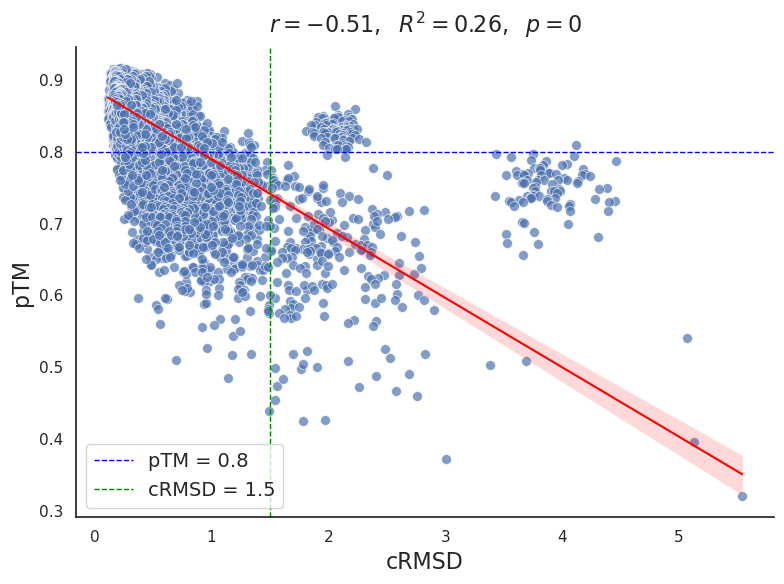

In [66]:
x = connector_df['cRMSD']
y = connector_df['pTM']

r, p_val = spearmanr(x, y)
# r, p_val = pearsonr(x, y)
r2 = r**2

sns.set(style="white")
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(x=x, y=y, s=50, alpha=0.7, ax=ax)

sns.regplot(
    x=x, y=y,
    scatter=False,
    ci=95,
    line_kws={'color':'red','lw':1.5},
    ax=ax
)

# pTM=0.8 and cRMSD=1.5
ax.axhline(0.8, color='blue',  linestyle='--', lw=1, label='pTM = 0.8')
ax.axvline(1.5, color='green', linestyle='--', lw=1, label='cRMSD = 1.5')

title_str = (
    f"$r={r:.2f},\\ \\;R^2={r2:.2f},\\ \\;p={p_val:.2g}$"
)

ax.set_title(
    title_str,
    loc='center',            # 'left' / 'center' / 'right'
    fontsize=16,
    pad=10,                 
    fontstyle='italic'      
)

ax.set_xlabel('cRMSD', fontsize=16)
ax.set_ylabel('pTM',   fontsize=16)
# ax.set_title('Scatter: cRMSD vs. pTM', fontsize=16)

ax.legend(loc='lower left', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

plt.savefig(f"{fig_save_path}/scatter_cRMSD_pTM_spearmanr.png", dpi=600, bbox_inches='tight')

plt.show()


In [ ]:
def filter_by_crmsd_ptm(
    df: pd.DataFrame,
    crmsd_col: str = "cRMSD",
    ptm_col: str = "pTM",
    crmsd_max: float = 1.5,
    ptm_min: float = 0.8,
    drop_na: bool = True,
    inplace: bool = False,
):
    """
    去掉不符合质量阈值的行：cRMSD > crmsd_max 或 pTM < ptm_min。
    保留：cRMSD <= crmsd_max 且 pTM >= ptm_min。
    Parameters
    ----------
    drop_na : bool
        True 时先丢弃 cRMSD/pTM 任一为 NaN 的行，再应用阈值。
    inplace : bool
        True 时在原 DataFrame 上就地过滤并返回同一对象（慎用）。
    """
    work = df if inplace else df.copy()
    n_before = len(work)
    if drop_na:
        work.dropna(subset=[crmsd_col, ptm_col], inplace=True)
    bad_crmsd = work[crmsd_col] > crmsd_max
    bad_ptm = work[ptm_col] < ptm_min
    remove_mask = bad_crmsd | bad_ptm
    kept = work.loc[~remove_mask].copy()
    n_after = len(kept)
    print(
        f"[filter cRMSD/pTM] rows before: {n_before} | after: {n_after} | "
        f"removed: {n_before - n_after} "
        f"(cRMSD>{crmsd_max}: {bad_crmsd.sum()}, pTM<{ptm_min}: {bad_ptm.sum()}, "
        f"overlap counted once in removed)"
    )
    return kept

In [ ]:
# connector_df_filtered = filter_by_crmsd_ptm(connector_df)
# connector_df = connector_df_filtered

## Correlation

In [67]:
# p-value
def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

### Global

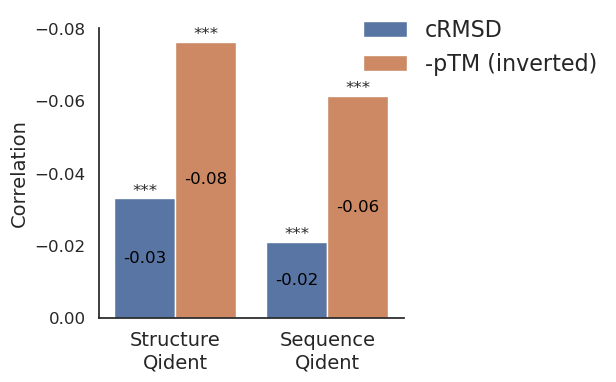

In [121]:
labels = ['structure_qident', 'sequence_qident']
targets = ['cRMSD', 'pTM']

rows = []
for lab in labels:
    for tgt in targets:
        corr, pval = spearmanr(connector_df[lab], connector_df[tgt])
        # Inversed pTM
        if tgt == 'pTM':
            corr = -corr
        rows.append({
            'label': lab,
            'correlation': corr,
            'p_value':    pval,
            'source':     tgt
        })
res_df = pd.DataFrame(rows)

xticks = ['Structure\nQident', 'Sequence\nQident']

sns.set(style="white")
fig, ax = plt.subplots(figsize=(6, 4))

palette = {
    'cRMSD': sns.color_palette("deep")[0],
    'pTM':   sns.color_palette("deep")[1]
}

sns.barplot(
    data=res_df,
    x='label', y='correlation',
    hue='source',
    palette=palette,
    dodge=True,
    ax=ax
)

ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=0, ha='center', fontsize=14)

for container in ax.containers:
    if isinstance(container, BarContainer):
        heights = [patch.get_height() for patch in container]
        labels  = [f"{h:.2f}" for h in heights]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',   
            padding=0,             
            fontsize=12,
            color='black'          
        )

for bar, p in zip(ax.patches, res_df['p_value']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        p_to_stars(p),
        ha='center', va='bottom',
        fontsize=12
    )

ax.set_xlabel('')
ax.set_ylabel('Correlation', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leg = ax.legend(
    title=None,
    loc='upper left',
    bbox_to_anchor=(0.8, 1.1),
    fontsize=16,
    frameon=False
)

for text in leg.get_texts():
    if text.get_text() == 'pTM':
        text.set_text('-pTM (inverted)')

ax.invert_yaxis()
plt.tight_layout()

plt.savefig(f"{fig_save_path}/global_similarity_spearmanr.png", dpi=600, bbox_inches='tight')
plt.show()


## Connector

In [78]:
region_list = ['all', 'connector1', 'connector2', 'connector3']
embe_list = ['raw_embeddings', 'pre_q_embeddings', 'ca_distance']
stage_list = ['original', 'grafted']

### Normalized

Batch generation did not normalized connector similarity

In [79]:

# Normalize based on length (connector: 4) and sqrt
for stage in stage_list:
    for region in region_list:
        for embe in embe_list:
            length = 12 if region == 'all' else 4
            col = f'{stage}_euclidean_{region}_{embe}'
            # print(f"{region} length = {length}")
            connector_df[f'{col}_norm'] = connector_df[col] / np.sqrt(length)

# Calculate change
for embe in embe_list:
    connector_df[f'change_euclidean_all_{embe}'] = abs(connector_df[f'original_euclidean_all_{embe}_norm'] - connector_df[f'grafted_euclidean_all_{embe}_norm'])

### Change calculation

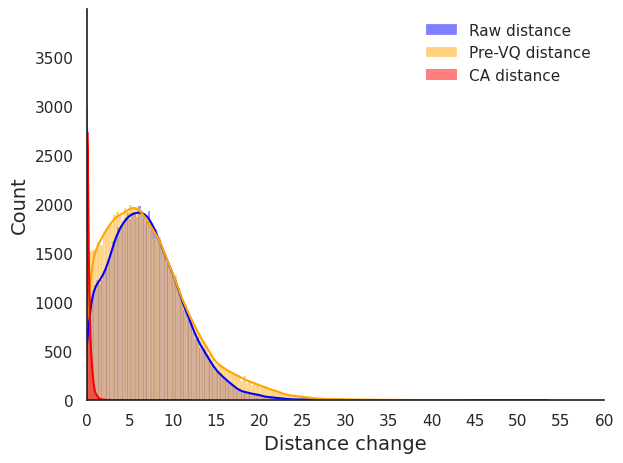

In [80]:
sns.histplot(connector_df['change_euclidean_all_raw_embeddings'],
             kde=True, label='Raw distance', color='blue')
sns.histplot(connector_df['change_euclidean_all_pre_q_embeddings'],
             kde=True, label='Pre-VQ distance', color='orange')
sns.histplot(connector_df['change_euclidean_all_ca_distance'],
             kde=True, label='CA distance', color='red')

plt.legend(frameon=False)

plt.xlabel('Distance change', fontsize=14)
plt.ylabel('Count', fontsize=14)

xmin, xmax = plt.xlim()
plt.xticks(np.arange(0, np.ceil(xmax) + 5, 5))
plt.xlim(left=0)

sns.despine(top=True, right=True)

plt.tight_layout()

# plt.savefig(f"{fig_save_path}/change_distance.png", dpi=600, bbox_inches='tight')
plt.show()


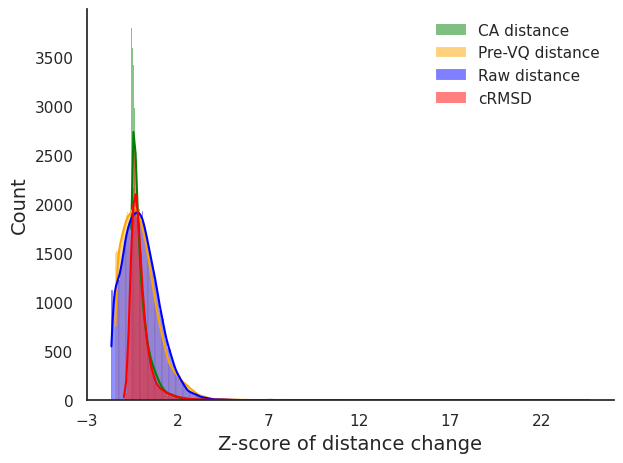

In [81]:
cols = [
    'cRMSD',
    'change_euclidean_all_raw_embeddings',
    'change_euclidean_all_pre_q_embeddings',
    'change_euclidean_all_ca_distance'
]

# Z-score：(x - mean) / std
z_cols = {}
for col in cols:
    series = connector_df[col].dropna()
    mean = series.mean()
    std  = series.std(ddof=1)
    z_cols[col] = (connector_df[col] - mean) / std

# Plot
sns.histplot(z_cols[cols[3]], kde=True, label='CA distance', color='green')
sns.histplot(z_cols[cols[2]], kde=True, label='Pre-VQ distance', color='orange')
sns.histplot(z_cols[cols[1]], kde=True, label='Raw distance', color='blue')
sns.histplot(z_cols[cols[0]], kde=True, label='cRMSD', color='red')

plt.legend(frameon=False)
plt.xlabel('Z-score of distance change', fontsize=14)
plt.ylabel('Count', fontsize=14)

xmin, xmax = plt.xlim()
plt.xticks(np.arange(np.floor(xmin), np.ceil(xmax) + 0.5, 5))
plt.xlim(left=np.floor(xmin))

sns.despine(top=True, right=True)

plt.tight_layout()

plt.savefig(f"{fig_save_path}/change_distance_z-score.png", dpi=600, bbox_inches='tight')
plt.show()


### Correlation

#### Full data correlation

In [82]:
# region_list = ['all']
embe_list = ['raw_embeddings', 'pre_q_embeddings', 'ca_distance']

def collect_results_pearson(df, stage, source_label, region_list, target='cRMSD'):
    rows = []
    for region in region_list:
        for embe in embe_list:
            col = f'{stage}_euclidean_{region}_{embe}_norm'
            r, p = pearsonr(df[col], df[target])
            rows.append({
                'region': region,
                'embedding': embe,
                'label': f'{region}_{embe}',
                # 'label': f'{embe}',
                'correlation': r,
                'p_value': p,
                'source': source_label
            })
    return pd.DataFrame(rows)

def collect_results_spearman(df, stage, source_label, region_list, target='cRMSD'):
    rows = []
    for region in region_list:
        for embe in embe_list:
            col = f'{stage}_euclidean_{region}_{embe}_norm'
            # 用 Spearman 相关替代 Pearson
            rho, pval = spearmanr(df[col], df[target])
            rows.append({
                'region':      region,
                'embedding':   embe,
                'label':       f'{region}_{embe}',
                'correlation': rho,
                'p_value':     pval,
                'source':      source_label
            })
    return pd.DataFrame(rows)


In [116]:
def plot_connector_correlation(res_df, target, xticks=None, figsize=(8, 5), x_rotation=None, invert=False, fontsize=14, legend_loc=0.8):

    sns.set(style="white")
    fig, ax = plt.subplots(figsize=figsize)

    # palette = {
    #     'Original connector': sns.color_palette("deep")[0],
    #     'Grafted connector':  sns.color_palette("deep")[1]
    # }
    palette = {
        'Original connector': '#4575D4',
        'Grafted connector':  '#6B9B00'
    }
    ax = sns.barplot(
        data=res_df,
        x='label', y='correlation',
        hue='source',
        palette=palette,
        dodge=True,
        ax=ax
    )

    if xticks:
        ax.set_xticks(range(len(xticks)))
        ax.set_xticklabels(
            xticks,
            fontsize=fontsize
        )
    
    if x_rotation:
        plt.xticks(rotation=x_rotation, ha='center', fontsize=fontsize)

    def format_r(val):
        return f"{val:.2f}"

    r_orig  = res_df[res_df['source']=='Original connector']['correlation'].values
    r_graft = res_df[res_df['source']=='Grafted connector']['correlation'].values

    for container, r_vals in zip(ax.containers, [r_orig, r_graft]):
        labels = [format_r(r_) for r_ in r_vals]
        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=fontsize-2,
            color='black'
        )

    # p-value
    for bar, p in zip(ax.patches, res_df['p_value']):
        stars = p_to_stars(p)
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            stars,
            ha='center', va='bottom',
            fontsize=12
        )

    ax.set_xlabel('')
    ax.set_ylabel(f'{target} correlation', fontsize=fontsize+2)
    ax.tick_params(axis='y', labelsize=fontsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    ax.legend(
        title=None,
        loc='upper left',
        bbox_to_anchor=(legend_loc, 1.05),
        borderaxespad=0,
        title_fontsize=fontsize,
        fontsize=fontsize+2,
        frameon=False
    )

    if invert:
        ax.invert_yaxis()

    plt.tight_layout()
    
    return plt

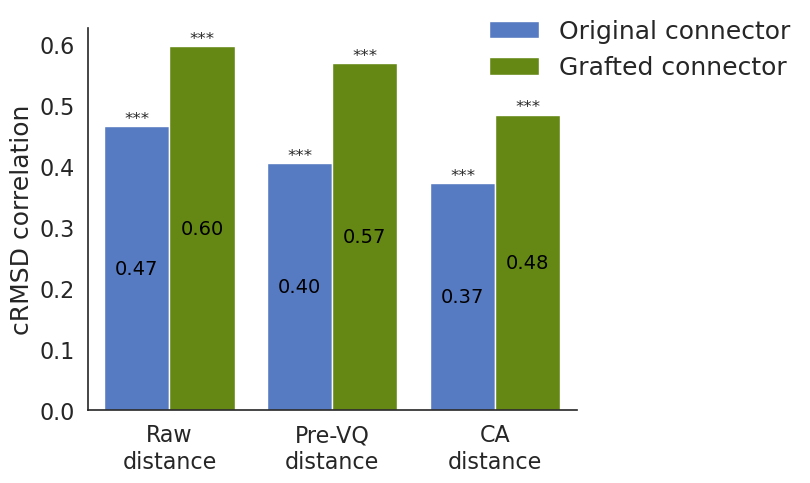

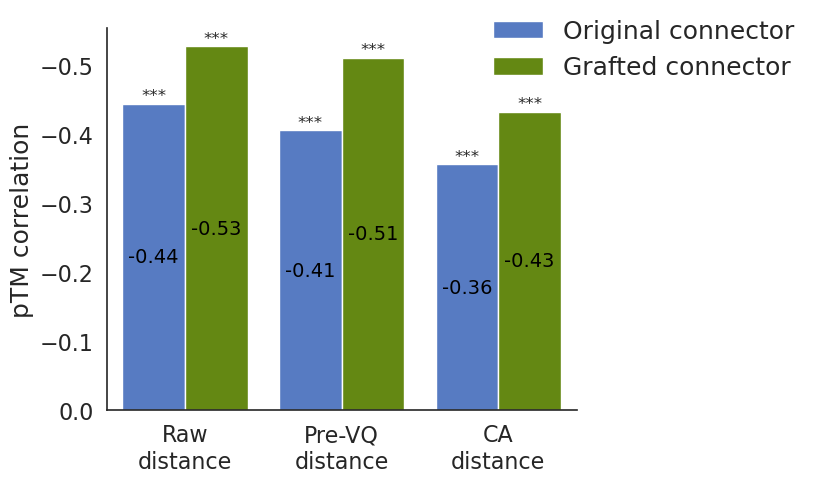

In [118]:
xticks=['Raw\ndistance', 'Pre-VQ\ndistance', 'CA\ndistance']
legend_loc = 0.8

crmsd_res_conn = collect_results_spearman(connector_df, stage='original', source_label='Original connector', region_list = ['all'], target='cRMSD')
crmsd_res_algn = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted connector', region_list = ['all'], target='cRMSD')
crmsd_res_df   = pd.concat([crmsd_res_conn, crmsd_res_algn], ignore_index=True)

crmsd_plt = plot_connector_correlation(crmsd_res_df, target='cRMSD', xticks=xticks, figsize=(8, 5), legend_loc=legend_loc, fontsize=16)
crmsd_plt.savefig(f"{fig_save_path}/connector_cRMSD_spearmanr.png", dpi=600, bbox_inches='tight')
crmsd_plt.show()

ptm_res_conn = collect_results_spearman(connector_df, stage='original', source_label='Original connector', region_list = ['all'], target='pTM')
ptm_res_algn = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted connector', region_list = ['all'], target='pTM')
ptm_res_df   = pd.concat([ptm_res_conn, ptm_res_algn], ignore_index=True)

ptm_plt = plot_connector_correlation(ptm_res_df, target='pTM', xticks=xticks, figsize=(8, 5), invert=True, legend_loc=legend_loc, fontsize=16)
ptm_plt.savefig(f"{fig_save_path}/connector_pTM_spearmanr.png", dpi=600, bbox_inches='tight')
ptm_plt.show()




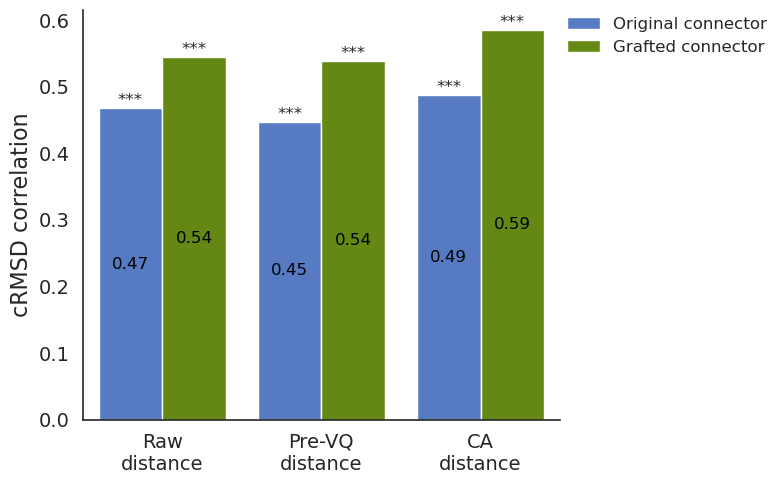

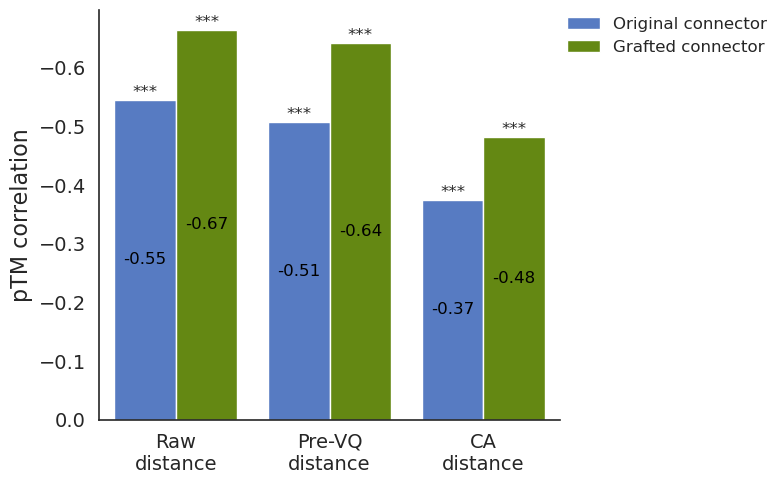

In [42]:
xticks=['Raw\ndistance', 'Pre-VQ\ndistance', 'CA\ndistance']
legend_loc = 1

crmsd_res_conn = collect_results_pearson(connector_df, stage='original', source_label='Original connector', region_list = ['all'], target='cRMSD')
crmsd_res_algn = collect_results_pearson(connector_df, stage='grafted', source_label='Grafted connector', region_list = ['all'], target='cRMSD')
crmsd_res_df   = pd.concat([crmsd_res_conn, crmsd_res_algn], ignore_index=True)

crmsd_plt = plot_connector_correlation(crmsd_res_df, target='cRMSD', xticks=xticks, figsize=(8, 5), legend_loc=legend_loc)
crmsd_plt.savefig(f"{fig_save_path}/connector_cRMSD_pearsonr.png", dpi=600, bbox_inches='tight')
crmsd_plt.show()

ptm_res_conn = collect_results_pearson(connector_df, stage='original', source_label='Original connector', region_list = ['all'], target='pTM')
ptm_res_algn = collect_results_pearson(connector_df, stage='grafted', source_label='Grafted connector', region_list = ['all'], target='pTM')
ptm_res_df   = pd.concat([ptm_res_conn, ptm_res_algn], ignore_index=True)

ptm_plt = plot_connector_correlation(ptm_res_df, target='pTM', xticks=xticks, figsize=(8, 5), invert=True, legend_loc=legend_loc)
ptm_plt.savefig(f"{fig_save_path}/connector_pTM_pearsonr.png", dpi=600, bbox_inches='tight')
ptm_plt.show()




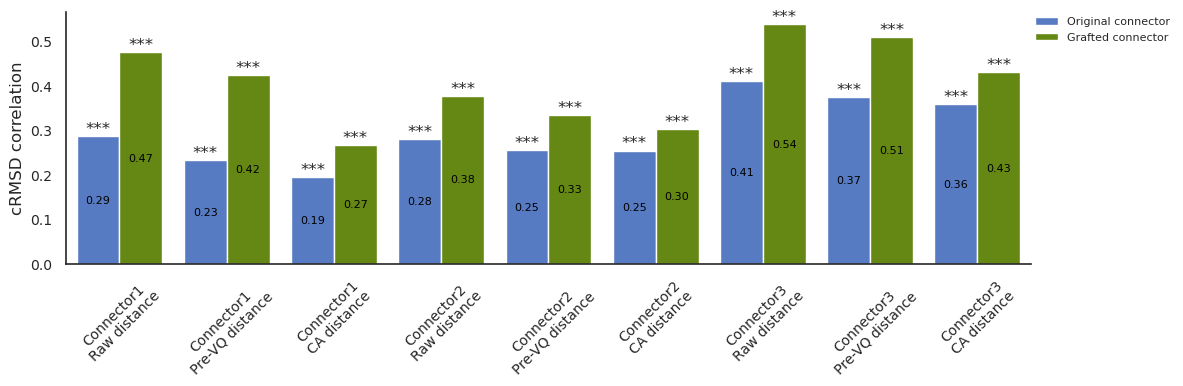

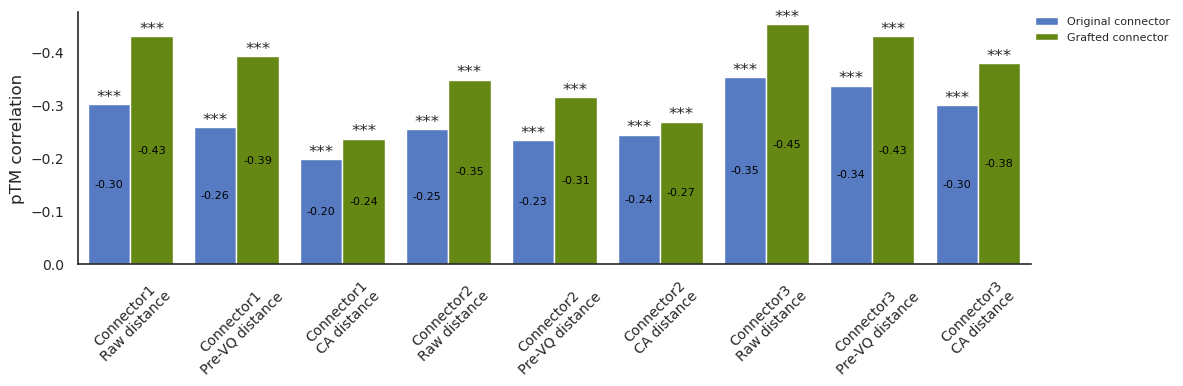

In [43]:
xticks = [f"{region}\n{embe}"
            for region in ['Connector1', 'Connector2', 'Connector3']
            for embe   in ['Raw distance', 'Pre-VQ distance', 'CA distance']]

fontsize = 10
legend_loc = 1

crmsd_res_conn_all = collect_results_spearman(connector_df, stage='original', source_label='Original connector', region_list = ['connector1', 'connector2', 'connector3'], target='cRMSD')
crmsd_res_algn_all = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted connector', region_list = ['connector1', 'connector2', 'connector3'], target='cRMSD')
crmsd_res_df_all = pd.concat([crmsd_res_conn_all, crmsd_res_algn_all], ignore_index=True)

crmsd_plt_all = plot_connector_correlation(crmsd_res_df_all, target='cRMSD', xticks=xticks, x_rotation=45, figsize=(12, 4), fontsize=fontsize, legend_loc=legend_loc)
crmsd_plt_all.savefig(f"{fig_save_path}/each_connector_cRMSD_spearmanr.png", dpi=600, bbox_inches='tight')
crmsd_plt_all.show()

ptm_res_conn_all = collect_results_spearman(connector_df, stage='original', source_label='Original connector', region_list = ['connector1', 'connector2', 'connector3'], target='pTM')
ptm_res_algn_all = collect_results_spearman(connector_df, stage='grafted', source_label='Grafted connector', region_list = ['connector1', 'connector2', 'connector3'], target='pTM')
ptm_res_df_all = pd.concat([ptm_res_conn_all, ptm_res_algn_all], ignore_index=True)

ptm_plt_all = plot_connector_correlation(ptm_res_df_all, target='pTM', xticks=xticks, x_rotation=45, figsize=(12, 4), invert=True, fontsize=fontsize, legend_loc=legend_loc)
ptm_plt_all.savefig(f"{fig_save_path}/each_connector_pTM_spearmanr.png", dpi=600, bbox_inches='tight')
ptm_plt_all.show()



#### Threshold

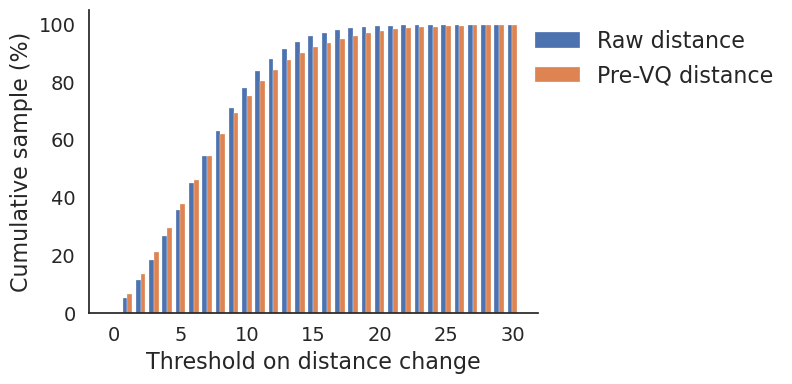

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Target embedding
embes = [
    ('raw_embeddings',   '-'),
    ('pre_q_embeddings', '--'),
]

# orig_color = '#4575D4'
# graf_color = '#6B9B00'
raw_color = sns.color_palette("deep")[0]
preq_color = sns.color_palette("deep")[1]

# Set thresholds
thresholds = np.arange(0, 31, 1)
step = 5

n_total = len(connector_df)
if n_total == 0:
    raise ValueError("connector_df is empty")

plt.figure(figsize=(8, 4))
ax = plt.gca()
plt.xticks(ha='center', fontsize=14)
plt.yticks(fontsize=14)

# ---------- 每个阈值下的「全体样本中」累积占比（左→右累加）----------
x = np.arange(len(thresholds))
width = 0.36
offsets = [-width / 2, width / 2]
bar_colors = [raw_color, preq_color]  # 与两条线风格区分，可按需改

for idx, (embe, linestyle) in enumerate(embes):
    change_col = f'change_euclidean_all_{embe}'
    cum_pct = [
        100.0 * (connector_df[change_col] <= th).sum() / n_total
        for th in thresholds
    ]
    ax.bar(
        x + offsets[idx],
        cum_pct,
        width,
        label=embe,
        color=bar_colors[idx],
        edgecolor='white',
        linewidth=0.2,
    )

ax.set_xlabel('Threshold on distance change', fontsize=16)
ax.set_ylabel('Cumulative sample (%)', fontsize=16)
ax.set_xticks(x[::step])
ax.set_xticklabels(thresholds[::step])

ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.legend(
#     fontsize=12,
#     frameon=False,
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1.0),
#     borderaxespad=0.0,
# )
# Self-defined legend
legend_entries = [
    "Raw distance",
    "Pre-VQ distance"
]
# ax.legend(legend_entries, loc='best', fontsize=10, frameon=False)
ax.legend(legend_entries, bbox_to_anchor=(0.95, 1), loc='upper left', fontsize=16, frameon=False)

plt.tight_layout()

plt.savefig(f"{fig_save_path}/threshold_on_distance_change_percent.png", dpi=600, bbox_inches='tight')

plt.show()

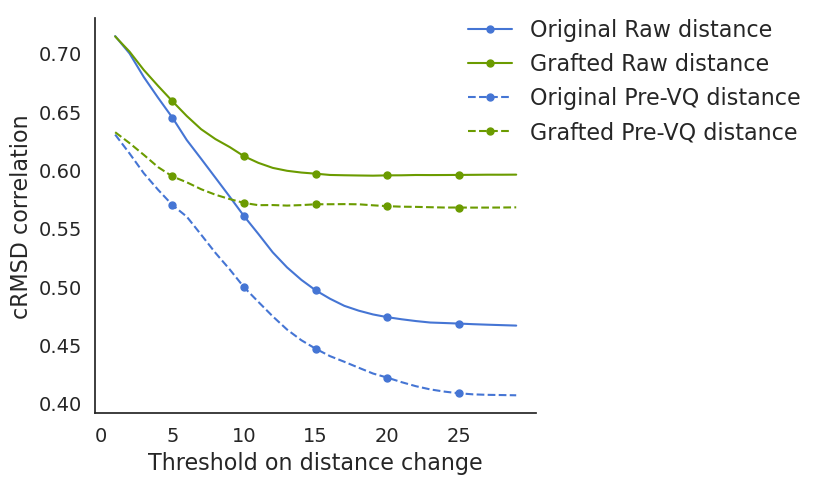

In [111]:
# Target embedding
embes = [
    ('raw_embeddings',   '-'),
    ('pre_q_embeddings', '--'),
]

orig_color = '#4575D4'
graf_color = '#6B9B00'
# palette = {
#     'Original connector': '#4575D4',
#     'Grafted connector':  '#6B9B00'
# }

# Set thresholds
thresholds = np.arange(0, 30, 1)
step = 5

plt.figure(figsize=(8, 5))
ax = plt.gca()

for embe, linestyle in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    corr_orig, p_orig = [], []
    corr_graf, p_graf = [], []
    
    for th in thresholds:
        df_filt = connector_df[connector_df[change_col] <= th]
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # r_orig, pval_orig = pearsonr(orig_value, df_filt['cRMSD'])
        # r_graf, pval_graf = pearsonr(graf_value, df_filt['cRMSD'])

        r_orig, pval_orig = spearmanr(orig_value, df_filt['cRMSD'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['cRMSD'])
        
        corr_orig.append(r_orig); p_orig.append(pval_orig)
        corr_graf.append(r_graf); p_graf.append(pval_graf)
    
    # Plot corr_orig
    line_orig, = ax.plot(
        thresholds, corr_orig,
        linestyle=linestyle, color=orig_color,
        marker='o', markevery=step, markersize=5,
        label=f"{embe} → Original"
    )
    
    # PLot corr_graf
    line_graf, = ax.plot(
        thresholds, corr_graf,
        linestyle=linestyle, color=graf_color,
        marker='o', markevery=step, markersize=5,
        label=f"{embe} → Grafted"
    )

ax.grid(False)

ax.set_xlabel('Threshold on distance change', fontsize=16)
ax.set_ylabel('cRMSD correlation', fontsize=16)
ax.set_xticks(thresholds[::step])
ax.tick_params(labelsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Self-defined legend
legend_entries = [
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
]
# ax.legend(legend_entries, loc='best', fontsize=10, frameon=False)
ax.legend(legend_entries, bbox_to_anchor=(0.80, 1.05), loc='upper left', fontsize=16, frameon=False)

plt.tight_layout()

plt.savefig(f"{fig_save_path}/threshold_on_distance_change_cRMSD.png", dpi=600, bbox_inches='tight')
plt.show()


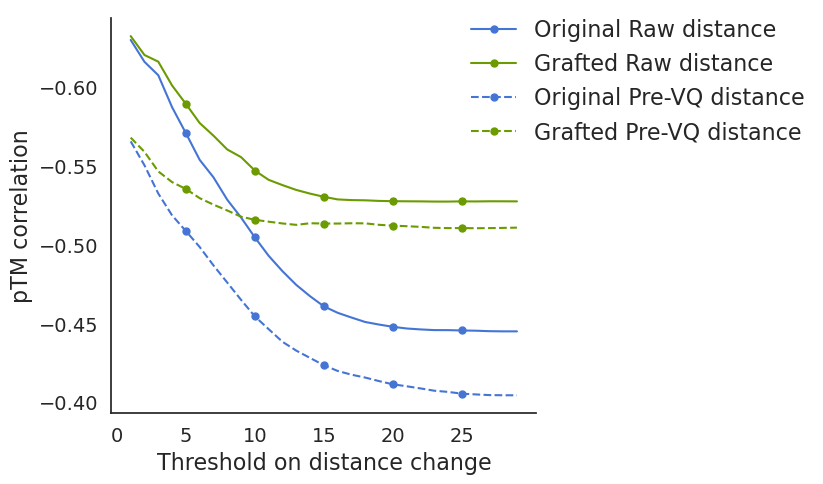

In [112]:
embes = [
    ('raw_embeddings',   '-'),
    ('pre_q_embeddings', '--'),
]

orig_color = '#4575D4'
graf_color = '#6B9B00'

# Set thresholds
thresholds = np.arange(0, 30, 1)
step = 5

plt.figure(figsize=(8, 5))
ax = plt.gca()

for embe, linestyle in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    corr_orig, p_orig = [], []
    corr_graf, p_graf = [], []
    
    for th in thresholds:
        df_filt = connector_df[connector_df[change_col] <= th]
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # r_orig, pval_orig = pearsonr(orig_value, df_filt['pTM'])
        # r_graf, pval_graf = pearsonr(graf_value, df_filt['pTM'])

        r_orig, pval_orig = spearmanr(orig_value, df_filt['pTM'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['pTM'])
        
        corr_orig.append(r_orig); p_orig.append(pval_orig)
        corr_graf.append(r_graf); p_graf.append(pval_graf)
    
    # Plot corr_orig
    line_orig, = ax.plot(
        thresholds, corr_orig,
        linestyle=linestyle, color=orig_color,
        marker='o', markevery=step, markersize=5,
        label=f"{embe} → Original"
    )
    
    # PLot corr_graf
    line_graf, = ax.plot(
        thresholds, corr_graf,
        linestyle=linestyle, color=graf_color,
        marker='o', markevery=step, markersize=5,
        label=f"{embe} → Grafted"
    )
    
ax.grid(False)

ax.set_xlabel('Threshold on distance change', fontsize=16)
ax.set_ylabel('pTM correlation', fontsize=16)
ax.set_xticks(thresholds[::step])
ax.tick_params(labelsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_entries = [
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
    "Original CA distance",
    "Grafted CA distance"
]
# ax.legend(legend_entries, loc='best', fontsize=10, frameon=False)
ax.legend(legend_entries, bbox_to_anchor=(0.80, 1.05), loc='upper left', fontsize=16, frameon=False)

ax.invert_yaxis()
plt.xticks(rotation=0, ha='center')

plt.tight_layout()

plt.savefig(f"{fig_save_path}/threshold_on_distance_change_pTM.png", dpi=600, bbox_inches='tight')
plt.show()


/tmp/ipykernel_728623/3247653685.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_connector_df[rank_col] = (


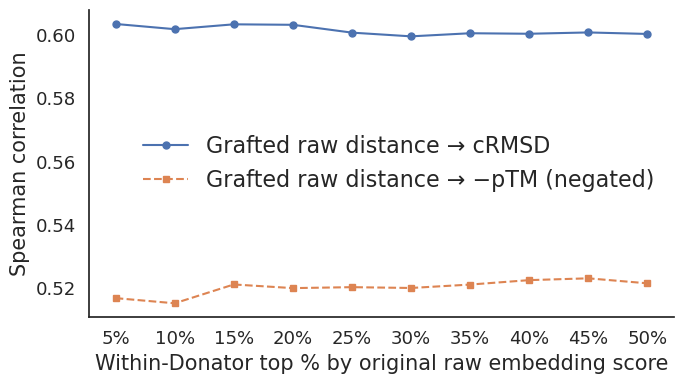

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

# 假设 connector_df 已加载，且含列 'cRMSD'、'pTM'（若列名不同请自行替换）
# ---------------------------------------------------------
if 'Donator' not in connector_df.columns:
    connector_df = connector_df.copy()
    connector_df['Donator'] = connector_df['PDB_ID'].astype(str).str.split('_').str[0]

orig_col = 'original_euclidean_all_raw_embeddings_norm'
graf_col = 'grafted_euclidean_all_raw_embeddings_norm'
change_col = 'change_euclidean_all_raw_embeddings'
change_th = 10.0

ptm_col = 'pTM'  # 若实际为 'ptm' 等，请改此处

# graf_color = '#6B9B00'
# ptm_color = '#C44E52'
graf_color = sns.color_palette("deep")[0]
ptm_color = sns.color_palette("deep")[1]

# 组内百分位秩：仍用 original raw 做排序/筛选（与原先一致）
rank_col = 'rank_pct_original_raw_within_donator'

filtered_connector_df = connector_df[connector_df[change_col] <= change_th]
filtered_connector_df[rank_col] = (
    filtered_connector_df.groupby('Donator')[orig_col].rank(pct=True, ascending=True) * 100
)

thresholds = np.arange(5, 55, 5)

corr_crmsd, corr_ptm = [], []
p_crmsd, p_ptm = [], []

for th in thresholds:
    df_filt = filtered_connector_df[filtered_connector_df[rank_col] <= th]
    if len(df_filt) < 2:
        corr_crmsd.append(np.nan)
        corr_ptm.append(np.nan)
        p_crmsd.append(np.nan)
        p_ptm.append(np.nan)
        continue

    # cRMSD：距离越大通常结构越差，与 grafted distance 同向解释
    r_c, pv_c = spearmanr(df_filt[graf_col], df_filt['cRMSD'])

    # pTM：与距离常为负相关；对 pTM 取反后再算 Spearman，使曲线方向可与 cRMSD 对照阅读
    r_p, pv_p = spearmanr(df_filt[graf_col], -df_filt[ptm_col])

    corr_crmsd.append(r_c)
    p_crmsd.append(pv_c)
    corr_ptm.append(r_p)
    p_ptm.append(pv_p)

plt.figure(figsize=(7, 4))
ax = plt.gca()

ax.plot(
    thresholds, corr_crmsd,
    color=graf_color, linestyle='-', marker='o', markersize=5,
    label='Grafted raw distance → cRMSD',
)
ax.plot(
    thresholds, corr_ptm,
    color=ptm_color, linestyle='--', marker='s', markersize=5,
    label='Grafted raw distance → −pTM (negated)',
)

ax.grid(False)
ax.set_xlabel('Within-Donator top % by original raw embedding score', fontsize=15)
ax.set_ylabel('Spearman correlation', fontsize=15)
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{int(t)}%' for t in thresholds])
ax.tick_params(labelsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='best', fontsize=16, frameon=False)

plt.tight_layout()
plt.savefig(f"{fig_save_path}/threshold_original_raw_pct_within_donator_crmsd_ptm.png", dpi=600, bbox_inches='tight')
plt.show()

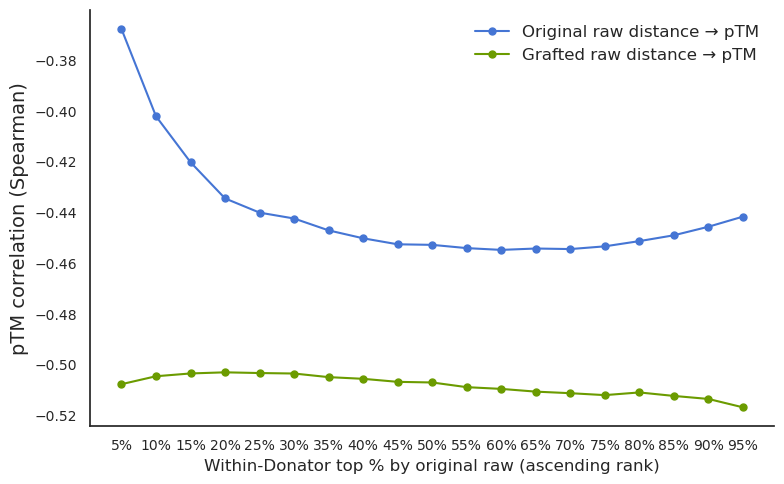

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

# 假设 connector_df 已加载
# ---------------------------------------------------------
if 'Donator' not in connector_df.columns:
    connector_df = connector_df.copy()
    connector_df['Donator'] = connector_df['PDB_ID'].astype(str).str.split('_').str[0]

# 仅用 original raw 做组内排序与筛选
orig_col = 'original_euclidean_all_raw_embeddings_norm'
graf_col = 'grafted_euclidean_all_raw_embeddings_norm'

orig_color = '#4575D4'
graf_color = '#6B9B00'

# 组内百分位秩：original raw 越小排名越靠前（距离越小越好时）
rank_col = 'rank_pct_original_raw_within_donator'
connector_df = connector_df.copy()
connector_df[rank_col] = (
    connector_df.groupby('Donator')[orig_col].rank(pct=True, ascending=True) * 100
)

# Top N%：保留组内 rank_pct <= N 的样本（约每个 Donator 内最优的 N%）
thresholds = np.arange(5, 100, 5)

corr_orig, corr_graf = [], []
p_orig, p_graf = [], []

for th in thresholds:
    df_filt = connector_df[connector_df[rank_col] <= th]
    if len(df_filt) < 2:
        corr_orig.append(np.nan)
        corr_graf.append(np.nan)
        p_orig.append(np.nan)
        p_graf.append(np.nan)
        continue

    r_o, pv_o = spearmanr(df_filt[orig_col], df_filt['pTM'])
    r_g, pv_g = spearmanr(df_filt[graf_col], df_filt['pTM'])
    corr_orig.append(r_o)
    p_orig.append(pv_o)
    corr_graf.append(r_g)
    p_graf.append(pv_g)

plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.plot(
    thresholds, corr_orig,
    color=orig_color, linestyle='-', marker='o', markersize=5,
    label='Original raw distance → pTM',
)
ax.plot(
    thresholds, corr_graf,
    color=graf_color, linestyle='-', marker='o', markersize=5,
    label='Grafted raw distance → pTM',
)

ax.grid(False)
ax.set_xlabel('Within-Donator top % by original raw (ascending rank)', fontsize=12)
ax.set_ylabel('pTM correlation (Spearman)', fontsize=14)
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{int(t)}%' for t in thresholds])
ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='best', fontsize=12, frameon=False)

plt.tight_layout()
# plt.savefig(f"{fig_save_path}/threshold_original_raw_pct_within_donator_pTM.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

# 假设 connector_df 已经被加载
# ---------------------------------------------------------

# 1. 根据 PDB_ID 获取 Donator 信息
# 格式为 Donator_Carrier (例如 5m2mE_6v7yF -> Donator: 5m2mE)
if 'Donator' not in connector_df.columns:
    connector_df['Donator'] = connector_df['PDB_ID'].apply(lambda x: x.split('_')[0])

# Target embedding 配置
embes = [
    ('raw_embeddings',   '-'),
    ('pre_q_embeddings', '--'),
]

orig_color = '#4575D4'
graf_color = '#6B9B00'

# 2. & 3. 设置百分比阈值 (Top X%)
# 注意：原代码是 0-50，但 0% 通常没有数据。
# 这里改为从 5% 到 50%，步长为 5 (即取每组中 change 最小的前 5%, 10% ... 50% 的样本)
thresholds = np.arange(5, 55, 5) 
step = 1 # 因为 thresholds 列表变短了，这里 markevery 设为 1 即可，或者保持原样逻辑

plt.figure(figsize=(8, 5))
ax = plt.gca()

for embe, linestyle in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    # --- 核心改进步骤 ---
    # 计算每个 Donator 组内的 Rank 百分比
    # pct=True 会返回 0.0 到 1.0 之间的数值，乘以 100 方便后续处理
    # ascending=True 表示 change 越小（越接近0），排名越靠前（百分比越小）
    rank_col = f'rank_pct_{embe}'
    connector_df[rank_col] = connector_df.groupby('Donator')[change_col].rank(pct=True, ascending=True) * 100
    
    corr_orig, p_orig = [], []
    corr_graf, p_graf = [], []
    
    # 4. 使用不同的百分比阈值进行过滤和计算
    for th in thresholds:
        # 过滤：只保留组内排名在当前百分比阈值内的样本
        df_filt = connector_df[connector_df[rank_col] <= th]
        
        # 为了防止样本过少导致计算报错（例如 th=5% 时可能某些组为空），加个简单判断
        if len(df_filt) < 2:
            corr_orig.append(np.nan)
            corr_graf.append(np.nan)
            continue
            
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # 计算 Spearman 相关性
        r_orig, pval_orig = spearmanr(orig_value, df_filt['cRMSD'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['cRMSD'])
        
        corr_orig.append(r_orig)
        p_orig.append(pval_orig)
        corr_graf.append(r_graf)
        p_graf.append(pval_graf)
    
    # Plot corr_orig
    line_orig, = ax.plot(
        thresholds, corr_orig,
        linestyle=linestyle, color=orig_color,
        marker='o', markersize=5, # markevery=step
        label=f"{embe} → Original"
    )
    
    # PLot corr_graf
    line_graf, = ax.plot(
        thresholds, corr_graf,
        linestyle=linestyle, color=graf_color,
        marker='o', markersize=5, # markevery=step
        label=f"{embe} → Grafted"
    )

ax.grid(False)

# 5. 更新轴标签和图例
ax.set_xlabel('Percentage threshold on distance change', fontsize=12)
ax.set_ylabel('cRMSD correlation', fontsize=14)

# 设置 X 轴刻度
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{int(t)}%' for t in thresholds]) # 添加 % 符号

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Self-defined legend
legend_entries = [
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
]

# 调整图例位置，避免遮挡
ax.legend(legend_entries, bbox_to_anchor=(0.80, 1), loc='upper left', fontsize=12, frameon=False)

plt.tight_layout()

# 保存图片
plt.savefig(f"{fig_save_path}/threshold_on_distance_change_percentage_cRMSD.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
ax = plt.gca()

for embe, linestyle in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    # --- 核心改进步骤 ---
    # 计算每个 Donator 组内的 Rank 百分比
    # pct=True 会返回 0.0 到 1.0 之间的数值，乘以 100 方便后续处理
    # ascending=True 表示 change 越小（越接近0），排名越靠前（百分比越小）
    rank_col = f'rank_pct_{embe}'
    connector_df[rank_col] = connector_df.groupby('Donator')[change_col].rank(pct=True, ascending=True) * 100
    
    corr_orig, p_orig = [], []
    corr_graf, p_graf = [], []
    
    # 4. 使用不同的百分比阈值进行过滤和计算
    for th in thresholds:
        # 过滤：只保留组内排名在当前百分比阈值内的样本
        df_filt = connector_df[connector_df[rank_col] <= th]
        
        # 为了防止样本过少导致计算报错（例如 th=5% 时可能某些组为空），加个简单判断
        if len(df_filt) < 2:
            corr_orig.append(np.nan)
            corr_graf.append(np.nan)
            continue
            
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # 计算 Spearman 相关性
        r_orig, pval_orig = spearmanr(orig_value, df_filt['pTM'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['pTM'])
        
        corr_orig.append(r_orig)
        p_orig.append(pval_orig)
        corr_graf.append(r_graf)
        p_graf.append(pval_graf)
    
    # Plot corr_orig
    line_orig, = ax.plot(
        thresholds, corr_orig,
        linestyle=linestyle, color=orig_color,
        marker='o', markersize=5, # markevery=step
        label=f"{embe} → Original"
    )
    
    # PLot corr_graf
    line_graf, = ax.plot(
        thresholds, corr_graf,
        linestyle=linestyle, color=graf_color,
        marker='o', markersize=5, # markevery=step
        label=f"{embe} → Grafted"
    )

ax.grid(False)

# 5. 更新轴标签和图例
ax.set_xlabel('Percentage threshold on distance change', fontsize=12)
ax.set_ylabel('pTM correlation', fontsize=14)

# 设置 X 轴刻度
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{int(t)}%' for t in thresholds]) # 添加 % 符号

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Self-defined legend
legend_entries = [
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
]

# 调整图例位置，避免遮挡
ax.legend(legend_entries, bbox_to_anchor=(0.80, 1), loc='upper left', fontsize=12, frameon=False)
ax.invert_yaxis()

plt.tight_layout()

# 保存图片
plt.savefig(f"{fig_save_path}/threshold_on_distance_change_percentage_pTM.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

# 假设 connector_df 已经被加载
# ---------------------------------------------------------

# 1. 根据 PDB_ID 获取 Donator 信息
if 'Donator' not in connector_df.columns:
    connector_df['Donator'] = connector_df['PDB_ID'].apply(lambda x: x.split('_')[0])

# Target embedding 配置
embes =[
    ('raw_embeddings',   '-'),
    ('pre_q_embeddings', '--'),
]

orig_color = '#4575D4'
graf_color = '#6B9B00'

thresholds = np.arange(5, 55, 5) 

# 获取过滤前的总样本数
total_samples = len(connector_df)

plt.figure(figsize=(8, 5))
ax = plt.gca()

for embe, linestyle in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    # 找到每个 Donator 组内的 Top 1 (即 change 最小值)
    min_change_col = connector_df.groupby('Donator')[change_col].transform('min')
    
    # 取每组前 5% 位置的值作为“高质量边界标尺” (quantile(0.05))
    top10pct_boundary_col = connector_df.groupby('Donator')[change_col].transform(
        lambda x: x.quantile(0.1)
    )
    
    # 公式：(当前值 - Top1) / (前5%边界 - Top1) * 100
    diff_pct_col = f'diff_pct_from_top1_{embe}'
    connector_df[diff_pct_col] = (connector_df[change_col] - min_change_col) / (top10pct_boundary_col - min_change_col + 1e-8) * 100
    
    corr_orig, p_orig = [],[]
    corr_graf, p_graf = [], []
    remain_pcts =[]  # 记录每个阈值下的剩余样本百分比
    
    # 使用不同的差异百分比阈值进行过滤和计算
    for th in thresholds:
        # 过滤样本
        df_filt = connector_df[connector_df[diff_pct_col] <= th]
        
        # 计算剩余样本占总样本的百分比
        current_remain_pct = (len(df_filt) / total_samples) * 100
        remain_pcts.append(current_remain_pct)
        
        # 防止样本过少导致计算报错
        if len(df_filt) < 2:
            corr_orig.append(np.nan)
            corr_graf.append(np.nan)
            continue
            
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # 计算 Spearman 相关性
        r_orig, pval_orig = spearmanr(orig_value, df_filt['cRMSD'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['cRMSD'])
        
        corr_orig.append(r_orig)
        p_orig.append(pval_orig)
        corr_graf.append(r_graf)
        p_graf.append(pval_graf)
    
    # 绘制 corr_orig 曲线
    line_orig, = ax.plot(
        thresholds, corr_orig,
        linestyle=linestyle, color=orig_color,
        marker='o', markersize=5,
        label=f"{embe} → Original"
    )
    
    # 绘制 corr_graf 曲线
    line_graf, = ax.plot(
        thresholds, corr_graf,
        linestyle=linestyle, color=graf_color,
        marker='o', markersize=5,
        label=f"{embe} → Grafted"
    )
    
    # --- 仅在 Grafted 曲线上添加百分比标注 ---
    for i, th in enumerate(thresholds):
        pct_val = remain_pcts[i]
        
        # 仅标注 Grafted 曲线，并将文本统一放置在数据点正上方
        if not np.isnan(corr_graf[i]):
            ax.annotate(
                f"{pct_val:.2f}%",
                (th, corr_graf[i]),
                textcoords="offset points",
                xytext=(0, 6),               # 向上偏移 8 像素
                ha='center', va='bottom',    # 垂直对齐设为底部对齐，使其浮在点上方
                fontsize=10, 
                color='#333333'              # 字体颜色，使用深灰色避免喧宾夺主
            )

ax.grid(False)

# 更新轴标签和图例
ax.set_xlabel('Threshold of difference percentage from Top-1 (%)', fontsize=12)
ax.set_ylabel('cRMSD correlation', fontsize=14)

# 设置 X 轴刻度
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{int(t)}%' for t in thresholds])

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 自定义图例
legend_entries =[
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
]

ax.legend(legend_entries, bbox_to_anchor=(0.90, 1.1), loc='upper left', fontsize=12, frameon=False)

# 动态扩展 Y 轴顶部边距，防止最高点上方的文本被截断
ylim = ax.get_ylim()
y_range = ylim[1] - ylim[0]
ax.set_ylim(ylim[0], ylim[1] + y_range * 0.1)

plt.tight_layout()

# 保存图片
plt.savefig(f"{fig_save_path}/threshold_diff_percentage_from_top1_cRMSD.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

# 假设 connector_df 已经被加载
# ---------------------------------------------------------

# 1. 根据 PDB_ID 获取 Donator 信息
if 'Donator' not in connector_df.columns:
    connector_df['Donator'] = connector_df['PDB_ID'].apply(lambda x: x.split('_')[0])

# Target embedding 配置
embes =[
    ('raw_embeddings',   '-'),
    ('pre_q_embeddings', '--'),
]

orig_color = '#4575D4'
graf_color = '#6B9B00'

thresholds = np.arange(5, 55, 5) 

# 获取过滤前的总样本数
total_samples = len(connector_df)

plt.figure(figsize=(8, 5))
ax = plt.gca()

for embe, linestyle in embes:
    change_col = f'change_euclidean_all_{embe}'
    orig_col   = f'original_euclidean_all_{embe}_norm'
    graf_col   = f'grafted_euclidean_all_{embe}_norm'
    
    # 找到每个 Donator 组内的 Top 1 (即 change 最小值)
    min_change_col = connector_df.groupby('Donator')[change_col].transform('min')
    
    # 取每组前 5% 位置的值作为“高质量边界标尺” (quantile(0.05))
    top10pct_boundary_col = connector_df.groupby('Donator')[change_col].transform(
        lambda x: x.quantile(0.1)
    )
    
    # 公式：(当前值 - Top1) / (前5%边界 - Top1) * 100
    diff_pct_col = f'diff_pct_from_top1_{embe}'
    connector_df[diff_pct_col] = (connector_df[change_col] - min_change_col) / (top10pct_boundary_col - min_change_col + 1e-8) * 100
    
    corr_orig, p_orig = [],[]
    corr_graf, p_graf = [], []
    remain_pcts =[]  # 记录每个阈值下的剩余样本百分比
    
    # 使用不同的差异百分比阈值进行过滤和计算
    for th in thresholds:
        # 过滤样本
        df_filt = connector_df[connector_df[diff_pct_col] <= th]
        
        # 计算剩余样本占总样本的百分比
        current_remain_pct = (len(df_filt) / total_samples) * 100
        remain_pcts.append(current_remain_pct)
        
        # 防止样本过少导致计算报错
        if len(df_filt) < 2:
            corr_orig.append(np.nan)
            corr_graf.append(np.nan)
            continue
            
        orig_value = df_filt[orig_col]
        graf_value = df_filt[graf_col]
        
        # 计算 Spearman 相关性
        r_orig, pval_orig = spearmanr(orig_value, df_filt['pTM'])
        r_graf, pval_graf = spearmanr(graf_value, df_filt['pTM'])
        
        corr_orig.append(r_orig)
        p_orig.append(pval_orig)
        corr_graf.append(r_graf)
        p_graf.append(pval_graf)
    
    # 绘制 corr_orig 曲线
    line_orig, = ax.plot(
        thresholds, corr_orig,
        linestyle=linestyle, color=orig_color,
        marker='o', markersize=5,
        label=f"{embe} → Original"
    )
    
    # 绘制 corr_graf 曲线
    line_graf, = ax.plot(
        thresholds, corr_graf,
        linestyle=linestyle, color=graf_color,
        marker='o', markersize=5,
        label=f"{embe} → Grafted"
    )
    
    # --- 仅在 Grafted 曲线上添加百分比标注 ---
    for i, th in enumerate(thresholds):
        pct_val = remain_pcts[i]
        
        # 仅标注 Grafted 曲线，并将文本统一放置在数据点正上方
        if not np.isnan(corr_graf[i]):
            ax.annotate(
                f"{pct_val:.2f}%",
                (th, corr_graf[i]),
                textcoords="offset points",
                xytext=(0, 6),               # 向上偏移 8 像素
                ha='center', va='bottom',    # 垂直对齐设为底部对齐，使其浮在点上方
                fontsize=10, 
                color='#333333'              # 字体颜色，使用深灰色避免喧宾夺主
            )

ax.grid(False)

# 更新轴标签和图例
ax.set_xlabel('Threshold of difference percentage from Top-1 (%)', fontsize=12)
ax.set_ylabel('pTM correlation', fontsize=14)

# 设置 X 轴刻度
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{int(t)}%' for t in thresholds])

ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 自定义图例
legend_entries =[
    "Original Raw distance",
    "Grafted Raw distance",
    "Original Pre-VQ distance",
    "Grafted Pre-VQ distance",
]

ax.legend(legend_entries, bbox_to_anchor=(0.90, 1.1), loc='upper left', fontsize=12, frameon=False)

# 动态扩展 Y 轴顶部边距，防止最高点上方的文本被截断
ylim = ax.get_ylim()
y_range = ylim[1] - ylim[0]
ax.set_ylim(ylim[0], ylim[1] + y_range * 0.1)

ax.invert_yaxis()
plt.tight_layout()

# 保存图片
plt.savefig(f"{fig_save_path}/threshold_diff_percentage_from_top1_pTM.png", dpi=600, bbox_inches='tight')
plt.show()